

 ***Online Brand Communication of L’Oréal: A Sentiment and Topic Analysis of Brand-Published Online Content***

*This analysis focuses on brand-published content from L’Oréal’s official website. Therefore, the findings reflect the company’s digital communication strategy.*

**1. Installing Required Libraries**

In [ ]:
!pip install requests beautifulsoup4 pandas -q
!pip install nltk vaderSentiment textblob -q
!pip install gensim pyLDAvis wordcloud matplotlib openpyxl -q

print("Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 56.2 MB/s eta 0:00:00
Libraries installed


**Here, I install all required Python libraries:**

**requests** → for web scraping

**BeautifulSoup** → for parsing HTML

**pandas** → for data handling

**nltk, textblob, vaderSentiment** → for NLP & sentiment analysis

**gensim, pyLDAvis** → for topic modeling

**wordcloud, matplotlib** → for visualization

**openpyxl** → for Excel export

**-q **makes installation silent

**2. Importing Libraries**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

**I import all necessary libraries for:**

Web scraping (requests, BeautifulSoup)

Data manipulation (pandas)

Text processing  (re, nltk)

Tokenization & stopword removal

**3. Download NLTK Data**

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

**I download:**

punkt → tokenizer for splitting text into words

stopwords → common words to remove (e.g., "the", "is")

**4. Build Listing Page URLs**

In [ ]:
base_url = "https://www.lorealparis.co.in"

listing_pages = []

categories = [
    ("skin-care-blogs", "Skin Care"),
    ("hair-care-blogs", "Hair Care"),
    ("makeup-blogs", "Makeup"),
    ("hair-colour-blogs", "Hair Colour")
]

for cat, label in categories:

    for page in range(1,8):   # collect up to 7 pages

        if page == 1:
            url = f"{base_url}/beauty-magazine/{cat}"
        else:
            url = f"{base_url}/beauty-magazine/{cat}?page={page}"

        listing_pages.append((url, label))

**It defines:**

Base website URL

Blog categories

It prepares to scrape multiple pages for each category

**5. Set Headers**

In [ ]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0 Safari/537.36"
}

**Explanation:**

Mimics a real browser request

Prevents blocking by the website

**6.** **Test Request**

In [ ]:
import requests

response = requests.get(listing_pages[0][0], headers=headers)

print("Status:", response.status_code)

print(response.text[:300])

Status: 200





<!DOCTYPE html>
<html class="no-js no-touch" lang="en-IN">
<head>
    


<!-- OneTrust Cookies Consent Notice start for lorealparis.co.in -->
<script src="https://cdn.cookielaw.org/scripttemplates/otSDKStub.js" type="text/javascript" charset="UTF-8" data-domain-script="1a03821b-b1b1


**Here, it sends a test request to verify:**

Website access works

Response is valid (status code 200)

**7. Extract Article Links**

In [ ]:
from bs4 import BeautifulSoup
import requests

article_links = []

for page_url, category in listing_pages:

    response = requests.get(page_url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    links = soup.find_all("a", href=True)

    for link in links:

        href = link["href"]

        # look for any beauty magazine article
        if "beauty-magazine" in href:

            if href.startswith("/"):
                href = base_url + href

            if (href, category) not in article_links:
                article_links.append((href, category))

    print("Collected from:", page_url)

print("Total article links:", len(article_links))



Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs
Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs?page=2
Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs?page=3
Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs?page=4
Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs?page=5
Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs?page=6
Collected from: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs?page=7
Collected from: https://www.lorealparis.co.in/beauty-magazine/hair-care-blogs
Collected from: https://www.lorealparis.co.in/beauty-magazine/hair-care-blogs?page=2
Collected from: https://www.lorealparis.co.in/beauty-magazine/hair-care-blogs?page=3
Collected from: https://www.lorealparis.co.in/beauty-magazine/hair-care-blogs?page=4
Collected from: https://www.lorealparis.co.in/beauty-magazine/hair-care-blogs?p

**Explanation:**

It loops through listing pages

It extracts blog article URLs

It filters only valid "beauty-magazine" links

It converts relative links → full URLs

**8. Scrape Article Content**

In [ ]:
import time

data = []

for url, category in article_links:

    try:
        response = requests.get(url, headers=headers)

        soup = BeautifulSoup(response.text, "html.parser")

        paragraphs = soup.find_all("p")

        for p in paragraphs:

            text = p.get_text().strip()

            if len(text) > 30:

                data.append({
                    "url": url,
                    "category": category,
                    "text": text
                })

        print("Scraped:", url)

        time.sleep(1)

    except:
        print("Error:", url)

print("Total paragraphs:", len(data))

Scraped: https://www.lorealparis.co.in/beauty-magazine
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/benefits-of-vitamin-c-serum
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/what-is-face-serum
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/ultimate-guide-to-double-cleansing
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/everything-about-oil-cleansing-method
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/everything-you-need-to-know-about-hyperpigmentation
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/how-to-control-oil-on-face
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/best-creams-to-get-rid-of-baggy-eyes
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/top-rated-eye-cream-for-wrinkles
Scraped: https://www.lorealparis.co.in/beauty-magazine/skin-care-blogs/how-to-use-hyaluronic-acid-serum
Scra

**Explanation:**

It visits each article page

It extracts paragraph text

It filters meaningful text (length > 30)

**It stores:**

URL

Category

Text content

**9. Create DataFrame**

In [ ]:
df = pd.DataFrame(data)

df.head()

,url,category,text
0,https://www.lorealparis.co.in/beauty-magazine,Skin Care,Perfect your routine with the latest hairstyle...
1,https://www.lorealparis.co.in/beauty-magazine/...,Skin Care,Vitamin C serum has earned its spot as a skinc...
2,https://www.lorealparis.co.in/beauty-magazine/...,Skin Care,"Vitamin C serum unveils radiant complexions, m..."
3,https://www.lorealparis.co.in/beauty-magazine/...,Skin Care,Vitamin C serum benefits start with its abilit...
4,https://www.lorealparis.co.in/beauty-magazine/...,Skin Care,One of the top advantages of vitamin C serum i...


**Explanation:**

It converts scraped data into a structured table

**10. Dataset Size**

In [ ]:
print(len(df))

1391


**Explanation:**

It displays number of collected text entries

**11. Save Dataset**

In [ ]:
df.to_excel("loreal_dataset_1000.xlsx", index=False)

**Explanation:**

It saves raw dataset to Excel file

**12. Download File**

In [ ]:
from google.colab import files
files.download("loreal_dataset_1000.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Explanation:**

It downloads dataset to Google Colab

**13. Text Cleaning**

In [ ]:
df["clean_text"] = df["text"].str.lower()

df["clean_text"] = df["clean_text"].apply(lambda x: re.sub(r"http\S+", "", x))

df["clean_text"] = df["clean_text"].apply(lambda x: re.sub(r"[^a-z\s]", "", x))

stop_words = set(stopwords.words("english"))

df["clean_text"] = df["clean_text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

df["clean_text"] = df["clean_text"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

df = df[df["clean_text"].str.len() > 5]

df = df[df["text"].str.len() > 40]

df = df.drop_duplicates()

df[["text","clean_text"]].head()



,text,clean_text
0,Perfect your routine with the latest hairstyle...,perfect routine latest hairstyles hair color i...
1,Vitamin C serum has earned its spot as a skinc...,vitamin c serum earned spot skincare superstar...
2,"Vitamin C serum unveils radiant complexions, m...",vitamin c serum unveils radiant complexions ma...
3,Vitamin C serum benefits start with its abilit...,vitamin c serum benefits start ability fade du...
4,One of the top advantages of vitamin C serum i...,one top advantages vitamin c serum targeted at...


**Explanation:**

**It performs preprocessing:**

Lowercase conversion

Remove URLs

Remove special characters

Remove stopwords

Remove extra spaces

It filters short/invalid text

**14.** **Save Clean Data**

In [ ]:
df.to_excel("loreal_clean_dataset.xlsx", index=False)

**Explanation:**

It saves cleaned dataset

**15. Download Clean Dataset**

In [ ]:
from google.colab import files
files.download("loreal_clean_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Explanation:**

It downloads cleaned data file

**16.** **Dataset Analysis**

DATASET OVERVIEW
  Total data points  : 1,289
  Unique articles    : 58
  Avg words per para : 30.5

category
Skin Care      526
Makeup         388
Hair Care      318
Hair Colour     57


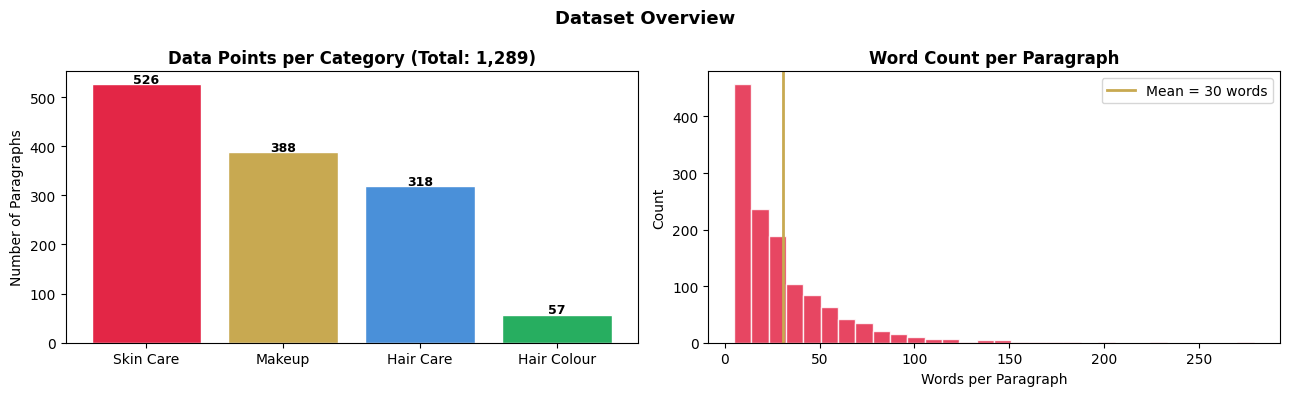

Saved: data_overview.png


In [ ]:
import matplotlib.pyplot as plt

df["word_count"] = df["text"].str.split().str.len()

print("DATASET OVERVIEW")
print("=" * 50)
print(f"  Total data points  : {len(df):,}")
print(f"  Unique articles    : {df['url'].nunique()}")
print(f"  Avg words per para : {df['word_count'].mean():.1f}")
print()
print(df["category"].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Dataset Overview", fontsize=13, fontweight="bold")

vc = df["category"].value_counts()
axes[0].bar(vc.index, vc.values,
            color=["#E32646", "#C8A951", "#4A90D9", "#27AE60"], edgecolor="white")
axes[0].set_title(f"Data Points per Category (Total: {len(df):,})", fontweight="bold")
axes[0].set_ylabel("Number of Paragraphs")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold", fontsize=9)

axes[1].hist(df["word_count"], bins=30, color="#E32646", alpha=0.85, edgecolor="white")
axes[1].axvline(df["word_count"].mean(), color="#C8A951", linewidth=2,
                label=f"Mean = {df['word_count'].mean():.0f} words")
axes[1].set_title("Word Count per Paragraph", fontweight="bold")
axes[1].set_xlabel("Words per Paragraph")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("data_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data_overview.png")

**Explanation:**

It computes:

Total entries

Unique articles

Average word count

Category distribution

It visualizes dataset stats using plots

**17. TF-IDF Keyword Extraction**

Top 10 TF-IDF keywords per category:

  Hair Care      : hair, scalp, hair fall, fall, winter, care, best, conditioner, serum, moisture
  Hair Colour    : hair, moisture, hair care, summer, hyaluron, care, hyaluronic, hyaluron moisture, loral, acid
  Makeup         : makeup, lipstick, infallible, fresh wear, look, mascara, foundation, skin, concealer, matte
  Skin Care      : skin, glycolic, acid, face, serum, glycolic acid, skincare, dark, spots, bright


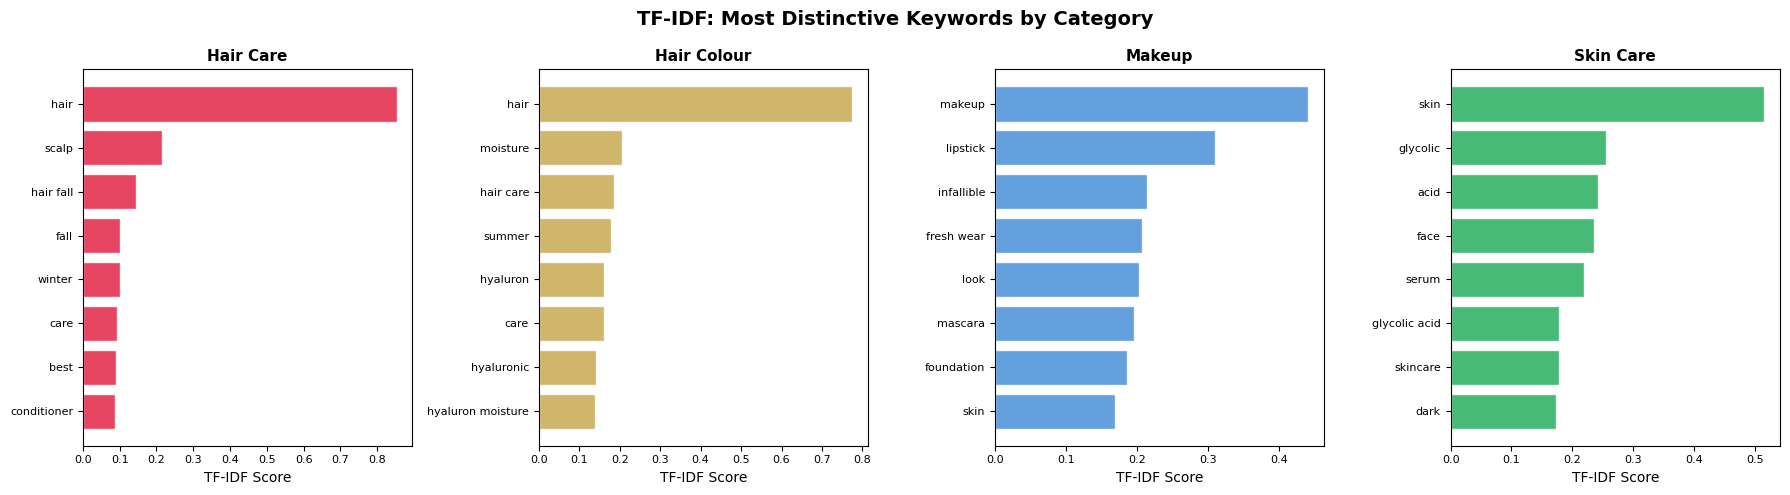

Saved: tfidf_keywords.png


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Combine all paragraphs from each category into one large document
category_docs = df.groupby("category")["clean_text"].apply(lambda x: " ".join(x)).reset_index()
category_docs.columns = ["category", "combined_text"]

# TF-IDF with bigrams to capture phrases like 'hyaluronic acid'
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=1)
tfidf_matrix = tfidf.fit_transform(category_docs["combined_text"])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=category_docs["category"],
    columns=tfidf.get_feature_names_out()
)

print("Top 10 TF-IDF keywords per category:\n")
for cat in tfidf_df.index:
    top10 = tfidf_df.loc[cat].sort_values(ascending=False).head(10)
    print(f"  {cat:<15}: {', '.join(top10.index.tolist())}")

colors = ["#E32646", "#C8A951", "#4A90D9", "#27AE60"]
fig, axes = plt.subplots(1, len(tfidf_df.index), figsize=(18, 5))
fig.suptitle("TF-IDF: Most Distinctive Keywords by Category", fontsize=14, fontweight="bold")

for ax, cat, col in zip(axes, tfidf_df.index, colors):
    top = tfidf_df.loc[cat].sort_values(ascending=False).head(8)
    ax.barh(top.index[::-1], top.values[::-1], color=col, alpha=0.85, edgecolor="white")
    ax.set_title(cat, fontweight="bold", fontsize=11)
    ax.set_xlabel("TF-IDF Score")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("tfidf_keywords.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tfidf_keywords.png")

**Explanation:**

It combines text by category

It extracts important keywords using TF-IDF

It includes bigrams

**18. Sentiment Analysis**

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import pandas as pd

vader = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """
    VADER compound thresholds (Hutto & Gilbert, 2014):
      >= 0.05  → Positive
      <= -0.05 → Negative
      otherwise → Neutral
    """
    vs = vader.polarity_scores(text)
    compound = vs["compound"]

    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"

    tb = TextBlob(text).sentiment
    return compound, label, round(tb.polarity, 4), round(tb.subjectivity, 4)

print(f"Running sentiment on {len(df):,} data points...")

# Apply to original text — VADER needs punctuation and capitalisation
df[["vader_compound", "sentiment_label", "tb_polarity", "tb_subjectivity"]] = \
    df["text"].apply(lambda x: pd.Series(get_sentiment(x)))

vc = df["sentiment_label"].value_counts()
total = len(df)
print(f"\nSentiment results — {total:,} data points:")
print("-" * 45)
for label, count in vc.items():
    bar = "\u2588" * int(count / total * 35)
    print(f"  {label:<10}: {count:5,} ({count/total*100:5.1f}%)  {bar}")
print("-" * 45)
print(f"  Avg VADER compound   : {df['vader_compound'].mean():+.4f}")
print(f"  Avg TextBlob polarity: {df['tb_polarity'].mean():+.4f}")
print(f"  Avg subjectivity     : {df['tb_subjectivity'].mean():.4f}  (0=objective, 1=subjective)")
print("\nAvg VADER by category:")
print(df.groupby("category")["vader_compound"].mean().sort_values(ascending=False).round(4).to_string())

Running sentiment on 1,289 data points...

Sentiment results — 1,289 data points:
---------------------------------------------
  Positive  :   881 ( 68.3%)  ███████████████████████
  Neutral   :   283 ( 22.0%)  ███████
  Negative  :   125 (  9.7%)  ███
---------------------------------------------
  Avg VADER compound   : +0.3889
  Avg TextBlob polarity: +0.1681
  Avg subjectivity     : 0.4385  (0=objective, 1=subjective)

Avg VADER by category:
category
Hair Colour    0.5734
Makeup         0.4574
Hair Care      0.3630
Skin Care      0.3341


**Explanation:**

It uses VADER sentiment analyzer

It classifies text into:

Positive

Negative

Neutral

Based on compound score thresholds

**19. Sentiment Visualization**

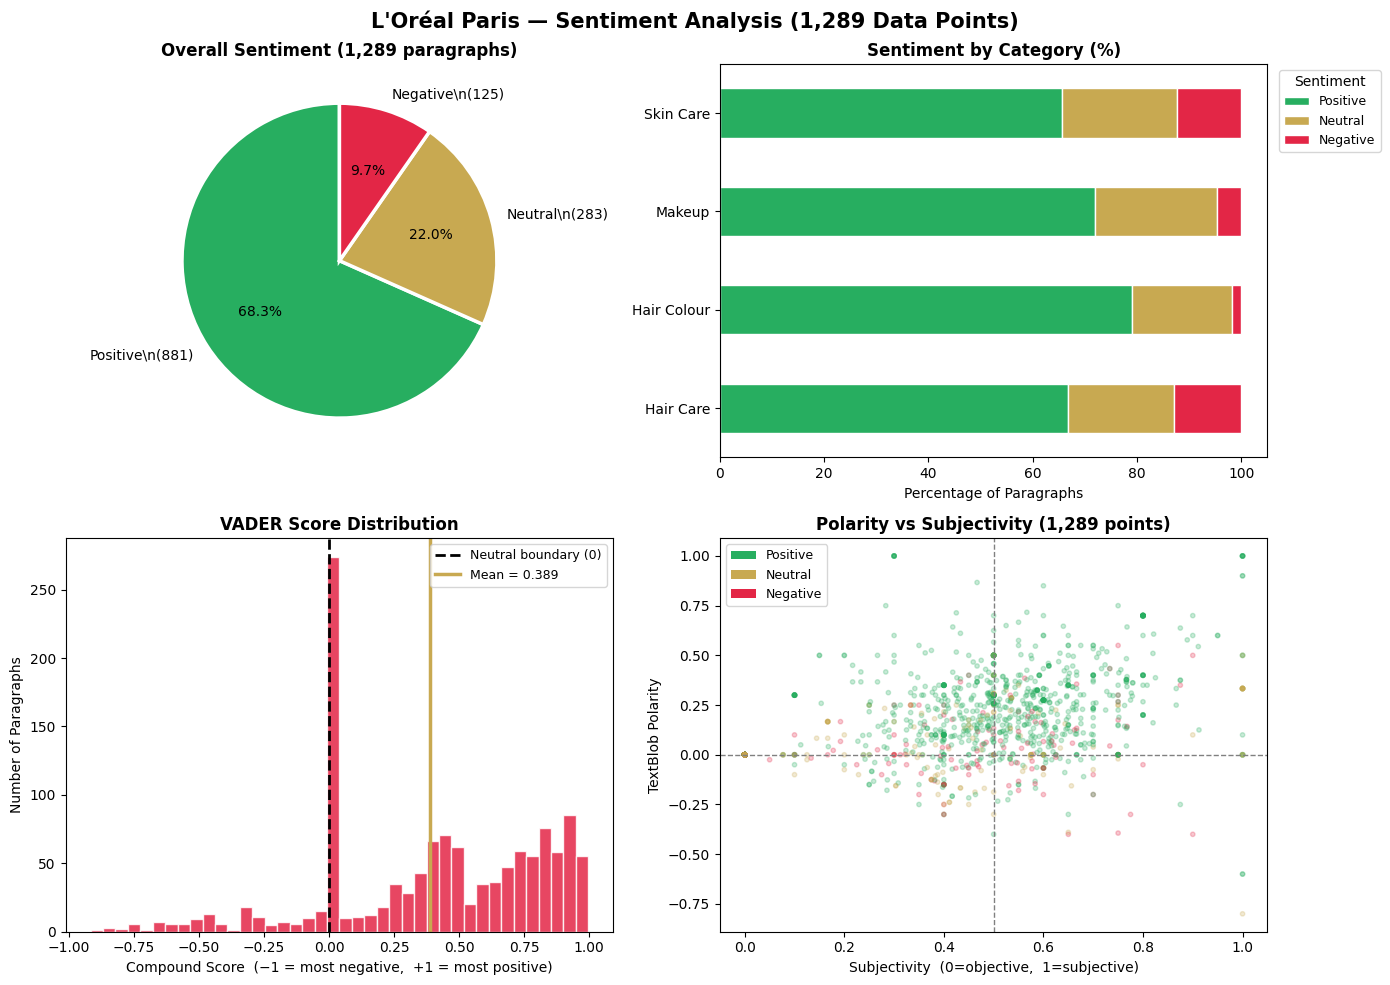

Saved: sentiment_analysis.png

5 MOST POSITIVE PARAGRAPHS:
  [+0.997] Complete your Gudi Padwa look with the perfect lip colour that will tie everything together. Make su...
  [+0.993] Ganesh Chaturthi is one of the most important festivals for Indians and is observed widely, especial...
  [+0.987] The first step to achieving a no makeup/clean girl look is to choose a  foundation. The right founda...
  [+0.986] With Gudi Padwa around the corner, it's time to embrace the festive spirit by donning your favourite...
  [+0.986] February is the month of celebrating love. Yes, we are talking about Valentine’s Day and the excitem...

5 MOST NEGATIVE PARAGRAPHS:
  [-0.917] The under-eye area is one of the most delicate parts of your face, and unfortunately, it’s also one ...
  [-0.840] If your skin is already inflamed, peeling, or reacting to another product, baking soda can worsen ir...
  [-0.827] Wondering how to fix dead hair? Indulge in this step-by-step damage hair repair routine to impro

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RED  = "#E32646"
GOLD = "#C8A951"
GRN  = "#27AE60"
SENT_COL = {"Positive": GRN, "Neutral": GOLD, "Negative": RED}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"L'Oréal Paris — Sentiment Analysis ({len(df):,} Data Points)",
             fontsize=15, fontweight="bold")

# Chart 1: Pie — overall sentiment
ax = axes[0, 0]
vc = df["sentiment_label"].value_counts()
ax.pie(
    vc.values,
    labels=[f"{l}\\n({v:,})" for l, v in zip(vc.index, vc.values)],
    colors=[SENT_COL[l] for l in vc.index],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 10}
)
ax.set_title(f"Overall Sentiment ({len(df):,} paragraphs)", fontweight="bold")

# Chart 2: Stacked bar — sentiment by category
ax = axes[0, 1]
pivot = df.groupby(["category", "sentiment_label"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
ordered = [c for c in ["Positive", "Neutral", "Negative"] if c in pivot_pct.columns]
pivot_pct[ordered].plot(
    kind="barh", stacked=True, ax=ax,
    color=[SENT_COL[c] for c in ordered], edgecolor="white"
)
ax.set_title("Sentiment by Category (%)", fontweight="bold")
ax.set_xlabel("Percentage of Paragraphs")
ax.legend(title="Sentiment", fontsize=9, bbox_to_anchor=(1.01, 1))
ax.set_ylabel("")

# Chart 3: Histogram — VADER score distribution
ax = axes[1, 0]
ax.hist(df["vader_compound"], bins=40, color=RED, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=2, linestyle="--", label="Neutral boundary (0)")
ax.axvline(df["vader_compound"].mean(), color=GOLD, linewidth=2.5,
           label=f"Mean = {df['vader_compound'].mean():.3f}")
ax.set_title("VADER Score Distribution", fontweight="bold")
ax.set_xlabel("Compound Score  (\u22121 = most negative,  +1 = most positive)")
ax.set_ylabel("Number of Paragraphs")
ax.legend(fontsize=9)

# Chart 4: Scatter — polarity vs subjectivity
ax = axes[1, 1]
colors_sc = [SENT_COL[l] for l in df["sentiment_label"]]
ax.scatter(df["tb_subjectivity"], df["tb_polarity"], c=colors_sc, alpha=0.25, s=10)
ax.axhline(0, color="grey", linewidth=1, linestyle="--")
ax.axvline(0.5, color="grey", linewidth=1, linestyle="--")
ax.set_xlabel("Subjectivity  (0=objective,  1=subjective)")
ax.set_ylabel("TextBlob Polarity")
ax.set_title(f"Polarity vs Subjectivity ({len(df):,} points)", fontweight="bold")
legend_els = [mpatches.Patch(facecolor=c, label=l) for l, c in SENT_COL.items()]
ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig("sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sentiment_analysis.png")

print("\n5 MOST POSITIVE PARAGRAPHS:")
for _, row in df.nlargest(5, "vader_compound")[["vader_compound", "text"]].iterrows():
    print(f"  [{row['vader_compound']:+.3f}] {row['text'][:100]}...")

print("\n5 MOST NEGATIVE PARAGRAPHS:")
for _, row in df.nsmallest(5, "vader_compound")[["vader_compound", "text"]].iterrows():
    print(f"  [{row['vader_compound']:+.3f}] {row['text'][:100]}...")

**Explanation:**

It creates charts:

Pie chart (overall sentiment)

Category-wise sentiment distribution

It uses custom brand-like colors

**20. Download Visuals**

In [ ]:
from google.colab import files

files.download("data_overview.png")
files.download("tfidf_keywords.png")
files.download("sentiment_analysis.png")
files.download("topic_model.png")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Explanation:**

It downloads generated charts

**21. Topic Modeling (LDA)**

In [ ]:
from gensim import corpora
from gensim.models import LdaModel
import numpy as np

texts = [row.split() for row in df["clean_text"] if len(row.split()) >= 5]

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=3, no_above=0.85)
corpus_lda = [dictionary.doc2bow(t) for t in texts]

print(f"LDA corpus   : {len(corpus_lda):,} paragraphs")
print(f"Vocabulary   : {len(dictionary):,} tokens after filtering")

np.random.seed(42)
lda = LdaModel(
    corpus       = corpus_lda,
    id2word      = dictionary,
    num_topics   = 6,
    random_state = 42,
    passes       = 20,
    alpha        = "auto",
    eta          = "auto"
)

print(f"\nLDA trained")
print(f"Log perplexity: {lda.log_perplexity(corpus_lda):.4f}  (lower = better fit)")
print("\nTop 8 keywords per topic:")
print("-" * 65)
for topic_id, topic in lda.show_topics(num_topics=6, num_words=8, formatted=False):
    kws = ", ".join([w for w, _ in topic])
    print(f"  Topic {topic_id}: {kws}")
print("-" * 65)
print("\nRead the keywords above and update topic_labels in Cell 12 to match what the model found.")

LDA corpus   : 1,281 paragraphs
Vocabulary   : 1,503 tokens after filtering

LDA trained
Log perplexity: -6.5101  (lower = better fit)

Top 8 keywords per topic:
-----------------------------------------------------------------
  Topic 0: hair, scalp, moisture, dry, oil, skin, winter, cleansing
  Topic 1: hair, routine, care, serum, fall, products, best, scalp
  Topic 2: skin, acid, serum, use, hyaluronic, glycolic, face, skincare
  Topic 3: h, wear, fresh, lipstick, infallible, foundation, matte, spots
  Topic 4: makeup, skin, look, day, valentines, face, eye, oil
  Topic 5: paris, loral, cream, face, glycolic, bright, serum, ml
-----------------------------------------------------------------

Read the keywords above and update topic_labels in Cell 12 to match what the model found.


**Explanation:**

It performs topic modeling using LDA

Steps:

Tokenize text

Create dictionary

Convert to bag-of-words

Train LDA model

It extracts hidden topics

**22. Topic Visualization**

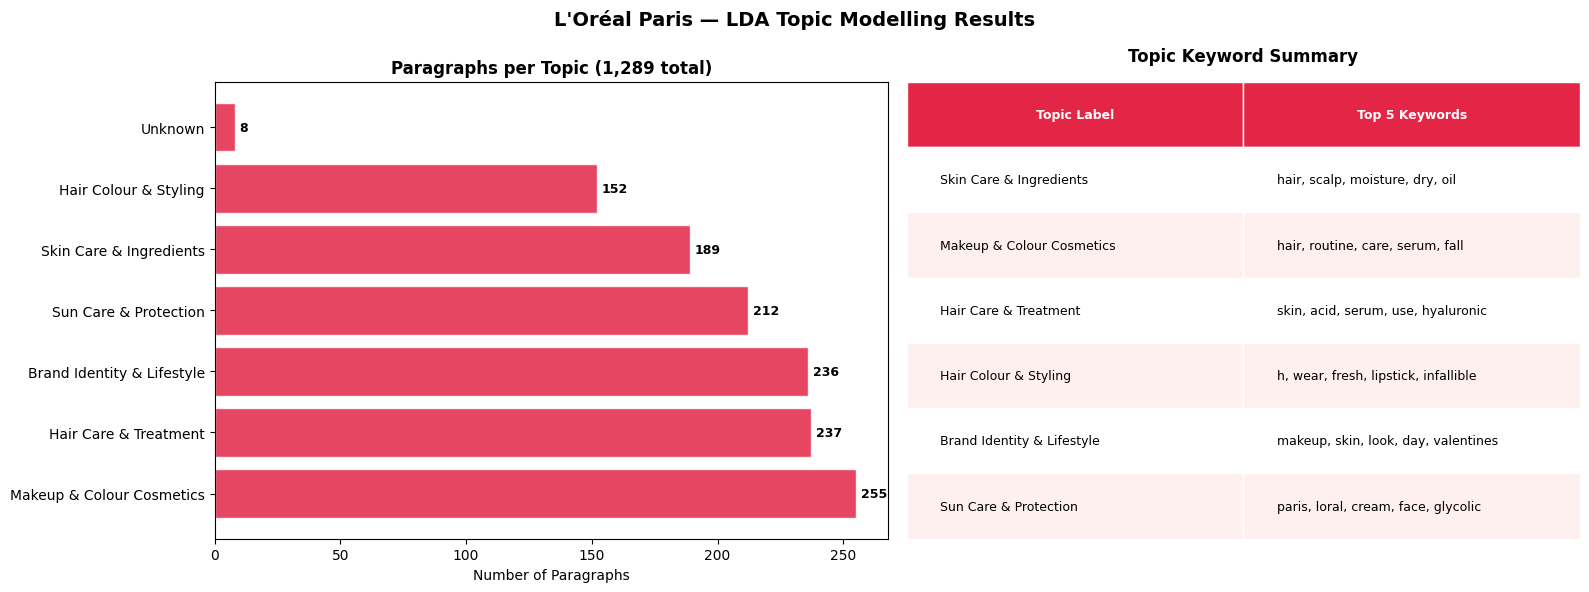

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved: topic_model.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved: lda_interactive.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Update these labels based on the keywords printed in Cell 11
topic_labels = {
    0: "Skin Care & Ingredients",
    1: "Makeup & Colour Cosmetics",
    2: "Hair Care & Treatment",
    3: "Hair Colour & Styling",
    4: "Brand Identity & Lifestyle",
    5: "Sun Care & Protection"
}

dominant_topics = []
topic_probs     = []

for bow in corpus_lda:
    scores = lda.get_document_topics(bow)
    if scores:
        best = max(scores, key=lambda x: x[1])
        dominant_topics.append(topic_labels.get(best[0], f"Topic {best[0]}"))
        topic_probs.append(round(best[1], 4))
    else:
        dominant_topics.append("Unknown")
        topic_probs.append(0.0)

pad = len(df) - len(dominant_topics)
df["dominant_topic"]    = dominant_topics + ["Unknown"] * pad
df["topic_probability"] = topic_probs     + [0.0]       * pad

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("L'Oréal Paris — LDA Topic Modelling Results", fontsize=14, fontweight="bold")

ax = axes[0]
tc = df["dominant_topic"].value_counts()
ax.barh(tc.index, tc.values, color="#E32646", alpha=0.85, edgecolor="white")
for i, v in enumerate(tc.values):
    ax.text(v + 2, i, str(v), va="center", fontsize=9, fontweight="bold")
ax.set_title(f"Paragraphs per Topic ({len(df):,} total)", fontweight="bold")
ax.set_xlabel("Number of Paragraphs")

ax = axes[1]
ax.axis("off")
table_data = [
    [topic_labels[i], ", ".join([w for w, _ in lda.show_topic(i, topn=5)])]
    for i in range(6)
]
tbl = ax.table(
    cellText=table_data,
    colLabels=["Topic Label", "Top 5 Keywords"],
    cellLoc="left", loc="center", bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#E32646")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#FFF0F0")
    cell.set_edgecolor("white")
ax.set_title("Topic Keyword Summary", fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("topic_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_model.png")

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda, corpus_lda, dictionary, mds="mmds", sort_topics=False)
pyLDAvis.save_html(vis, "lda_interactive.html")
print("Saved: lda_interactive.html")
pyLDAvis.display(vis)

**Explanation:**

It assigns labels to topics

It finds dominant topic per document

It prepares interactive visualization

**23. Word Cloud**

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

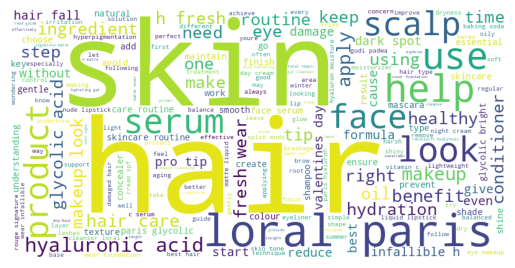

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved: wordcloud.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from google.colab import files

text = " ".join(df["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wordcloud.png")
files.download("wordcloud.png")

**Explanation:**

It generates word cloud from cleaned text

It highlights most frequent words

It saves and downloads image